In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def load_train(path):
    """Reads comma-separated x1,x2,label rows."""
    data = np.genfromtxt(path, delimiter=",")
    X = data[:, :-1]          # features
    y = data[:, -1].astype(int)  # labels
    return X, y


def load_test(path):
    """Reads comma-separated x1,x2 rows (no label)."""
    X = np.genfromtxt(path, delimiter=",")
    return X


X_train, y_train = load_train("train_knn.txt")
X_test = load_test("test_knn.txt")

print(f"Training samples: {X_train.shape[0]}, features: {X_train.shape[1]}")
print(f"Test samples: {X_test.shape[0]}")
print("Classes present:", np.unique(y_train))

Training samples: 14, features: 2
Test samples: 9
Classes present: [1 2]


# Training

/tmp/ipykernel_740/1705637251.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, max(len(classes), 3))


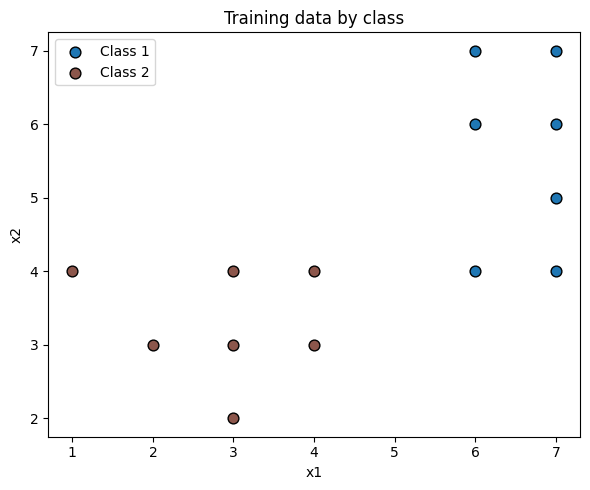

In [ ]:
def plot_by_label(X, y, title, cmap_name="tab10"):
    classes = np.unique(y)
    colors = plt.cm.get_cmap(cmap_name, max(len(classes), 3))

    plt.figure(figsize=(6, 5))
    for i, c in enumerate(classes):
        pts = X[y == c]
        plt.scatter(pts[:, 0], pts[:, 1], s=60, color=colors(i),
                    edgecolors="black", label=f"Class {c}")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_by_label(X_train, y_train, "Training data by class")

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))


def knn_predict(X_train, y_train, query, k):
    distances = euclidean_distance(X_train, query)

    order = np.argsort(distances)
    k_idx = order[:k]

    neighbor_info = [(distances[i], y_train[i]) for i in k_idx]

    neighbor_classes = y_train[k_idx]
    values, counts = np.unique(neighbor_classes, return_counts=True)
    predicted_class = values[np.argmax(counts)]

    return predicted_class, neighbor_info

In [ ]:
try:
    K = int(input("Enter the value of K: "))
except Exception:
    K = 3  # Default K
    print(f"No interactive input available — using default K = {K}")

print(f"Using K = {K}")

Enter the value of K: 3
Using K = 3


Test point (3, 7) -> Predicted class: 1
Test point (7, 7) -> Predicted class: 1
Test point (4, 3) -> Predicted class: 2
Test point (2, 8) -> Predicted class: 2
Test point (3, 5) -> Predicted class: 2
Test point (1, 2) -> Predicted class: 2
Test point (4, 8) -> Predicted class: 1
Test point (8, 3) -> Predicted class: 1
Test point (8, 4) -> Predicted class: 1


/tmp/ipykernel_740/1705637251.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, max(len(classes), 3))


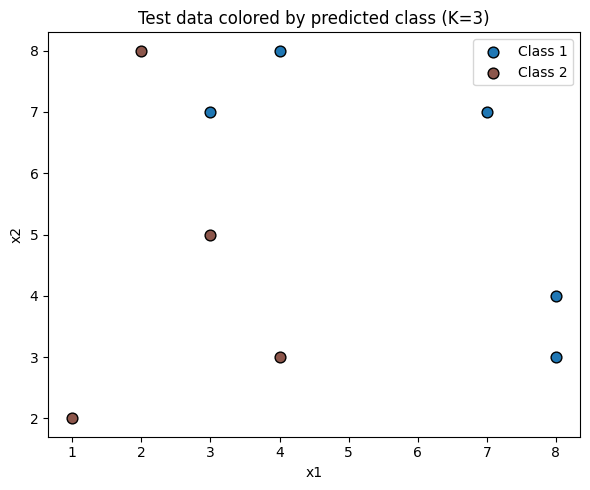

In [ ]:
predictions = []
all_neighbor_info = []

for query in X_test:
    pred, neighbors = knn_predict(X_train, y_train, query, K)
    predictions.append(pred)
    all_neighbor_info.append(neighbors)

predictions = np.array(predictions)

for pt, pred in zip(X_test, predictions):
    print(f"Test point ({pt[0]:.0f}, {pt[1]:.0f}) -> Predicted class: {pred}")

plot_by_label(X_test, predictions, f"Test data colored by predicted class (K={K})")

# Testing

In [ ]:
with open("prediction.txt", "w") as f:
    for pt, pred, neighbors in zip(X_test, predictions, all_neighbor_info):
        f.write(f"Test point: {pt[0]:.0f}, {pt[1]:.0f}\n")
        for rank, (dist, cls) in enumerate(neighbors, start=1):
            f.write(f"Distance {rank}: {dist:.2f} Class: {cls}\n")
        f.write(f"Predicted class: {pred}\n\n")

print("Saved prediction.txt")

Saved prediction.txt


In [ ]:
with open("prediction.txt") as f:
    print(f.read())

Test point: 3, 7
Distance 1: 3.00 Class: 2
Distance 2: 3.00 Class: 1
Distance 3: 3.16 Class: 1
Predicted class: 1

Test point: 7, 7
Distance 1: 0.00 Class: 1
Distance 2: 1.00 Class: 1
Distance 3: 1.00 Class: 1
Predicted class: 1

Test point: 4, 3
Distance 1: 0.00 Class: 2
Distance 2: 1.00 Class: 2
Distance 3: 1.00 Class: 2
Predicted class: 2

Test point: 2, 8
Distance 1: 4.12 Class: 2
Distance 2: 4.12 Class: 1
Distance 3: 4.12 Class: 2
Predicted class: 2

Test point: 3, 5
Distance 1: 1.00 Class: 2
Distance 2: 1.41 Class: 2
Distance 3: 2.00 Class: 2
Predicted class: 2

Test point: 1, 2
Distance 1: 1.41 Class: 2
Distance 2: 2.00 Class: 2
Distance 3: 2.00 Class: 2
Predicted class: 2

Test point: 4, 8
Distance 1: 2.24 Class: 1
Distance 2: 2.83 Class: 1
Distance 3: 3.16 Class: 1
Predicted class: 1

Test point: 8, 3
Distance 1: 1.41 Class: 1
Distance 2: 2.24 Class: 1
Distance 3: 2.24 Class: 1
Predicted class: 1

Test point: 8, 4
Distance 1: 1.00 Class: 1
Distance 2: 1.41 Class: 1
Distance 3:

Train:

7,7,1
7,4,1
6,4,1
7,5,1
7,6,1
6,7,1
6,6,1
3,4,2
2,3,2
3,2,2
4,3,2
3,3,2
4,4,2
1,4,2

Test:

3,7
7,7
4,3
2,8
3,5
1,2
4,8
8,3
8,4